# Car  Price Prediction Using Linear Regression

## 1. Problem Staement

###The objective of this project is to build a machine learning model that predicts the price of a car based on selected car characteristics.

###Since, the target variable is 'Price', which is a continous numerical value, this is a **Regression Problem**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Data Loading and Intial Exploration

In [2]:
df = pd.read_csv('scrap price.csv')

In [3]:
df.shape

(205, 26)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   name              205 non-null    object 
 3   fueltypes         205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumbers       205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheels       205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [5]:
df.head()

,ID,symboling,name,fueltypes,aspiration,doornumbers,carbody,drivewheels,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [6]:
df.describe()

,ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


# 3. Exploratory Data Analysis (EDA)

### Exploratory Data Analysis is performed to understand the relationships, distributions, and patterns present in the dataset before building the machine learning model.

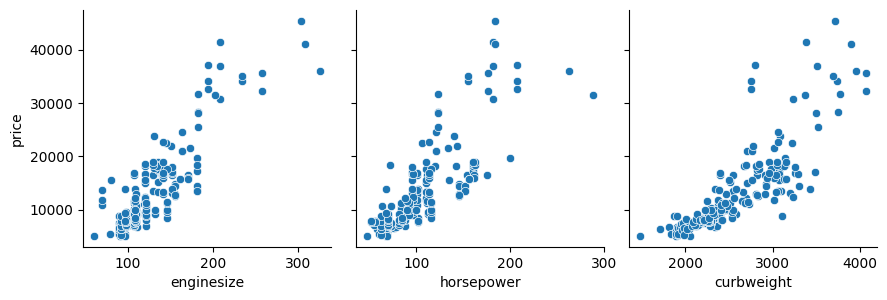

In [7]:
sns.pairplot(
    df,
    x_vars = ['enginesize','horsepower','curbweight'],
    y_vars = ['price'],
    height = 3
)

### **Observation :**
###Enginesize, horsepower and curbweight show an overall positive reltionship with car price. All these features increase, car price generally tend to increase, although the relationship is not perfectly linear

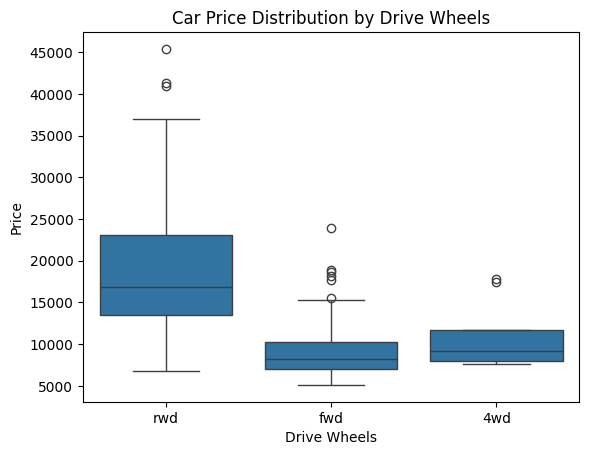

In [8]:
sns.boxplot(data=df, x="drivewheels", y='price')
plt.xlabel("Drive Wheels")
plt.ylabel("Price")
plt.title("Car Price Distribution by Drive Wheels")
plt.show()

### **Observation :**

### The price distribution varies across drive wheel categories. Rear Wheel drive cars generally have higher prices, while front wheel drive cars tend to have lower prices.
### This suggests that **drivewheels** may provide useful information for predicting car price

In [9]:
df["manufacturer"] = df["name"].str.split().str[0]
df["manufacturer"].value_counts()

,count
manufacturer,
toyota,31
nissan,17
mazda,15
honda,13
mitsubishi,13
subaru,12
volvo,11
peugeot,11
dodge,9


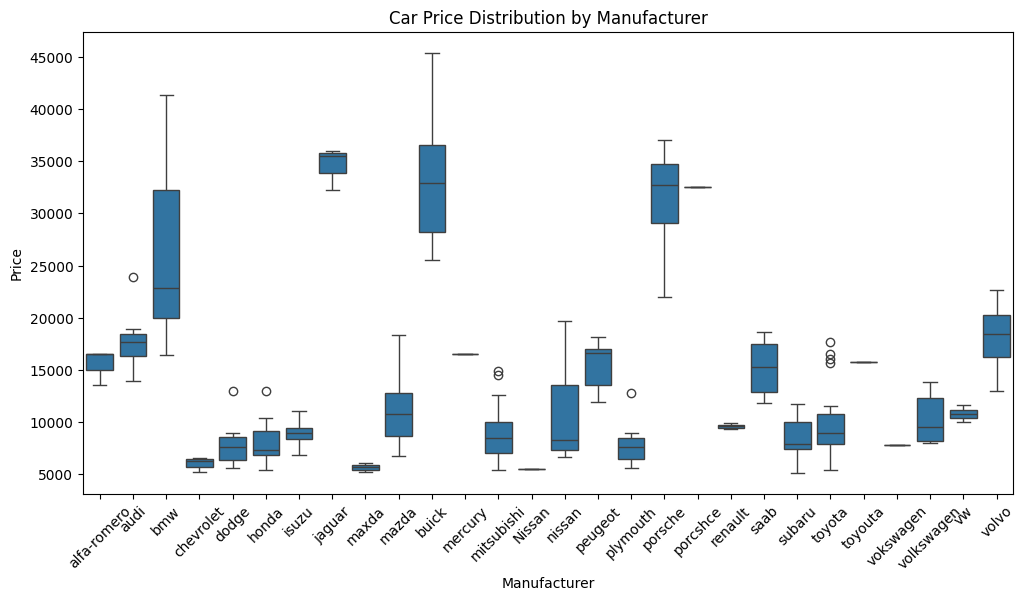

In [10]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df, x="manufacturer", y="price")
plt.xlabel("Manufacturer")
plt.ylabel("Price")
plt.title('Car Price Distribution by Manufacturer')
plt.xticks(rotation=45)

plt.show()

### **Observation :**

### Car price varies across differeny manufacturers. Some manufacturers generally have higher price distributions, while others tend to have lower price distributions. This suggest that **manufacturer** may be an important feature for predicting car price.

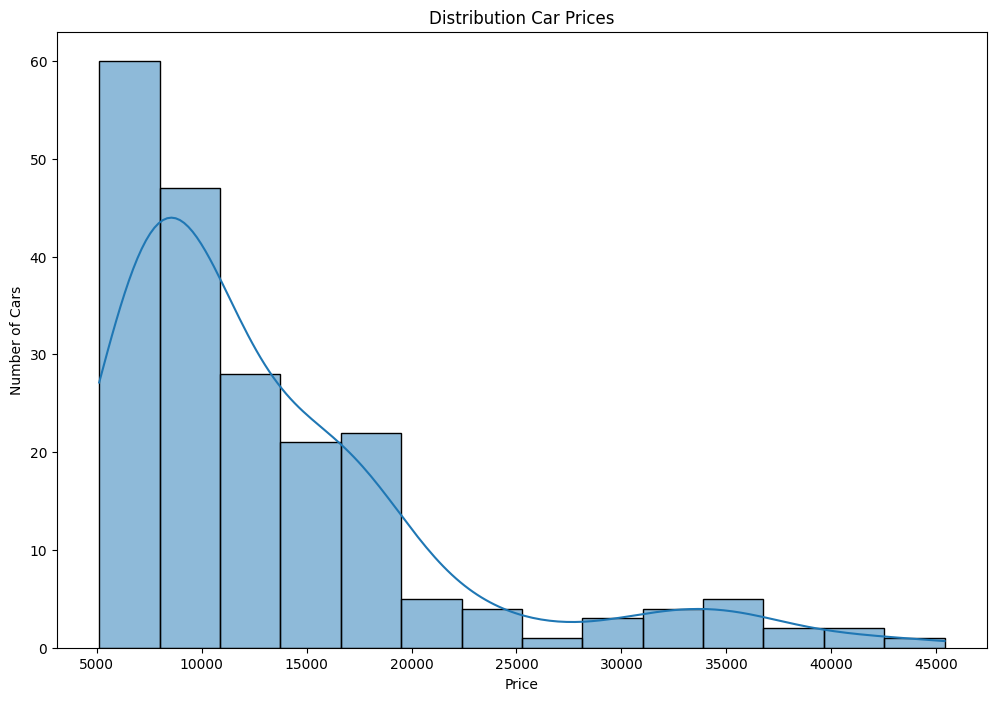

In [11]:
plt.figure(figsize=(12,8))

sns.histplot(df['price'], kde=True)
plt.xlabel("Price")
plt.ylabel("Number of Cars")
plt.title("Distribution Car Prices")

plt.show()

### **Observations**

### The car price distribution is right - skewed. Most cars are concentrated in the lower price range, while a  smaller number of cars have much higher prices, creating a longer tail towards the right.

In [12]:
correlation = df[['enginesize', 'horsepower', 'curbweight', 'price']].corr()

correlation

,enginesize,horsepower,curbweight,price
enginesize,1.000000,0.809769,0.850594,0.874145
horsepower,0.809769,1.000000,0.750739,0.808139
curbweight,0.850594,0.750739,1.000000,0.835305
price,0.874145,0.808139,0.835305,1.000000


### **Observation :**

### Engine size, horsepower, and curbweight are strongly correlated with one another, incidating the presence of potential multicollinearity among the numerical features which may affect the **Linear Regression Model**

In [13]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [14]:
vif_data = df[['enginesize','horsepower','curbweight']]

In [15]:
vif = pd.DataFrame()

vif['Feature'] = vif_data.columns

vif['VIF'] = [
    variance_inflation_factor(vif_data.values, i)
    for i in
    range(vif_data.shape[1])
]

vif

,Feature,VIF
0,enginesize,4.777126
1,horsepower,3.026707
2,curbweight,3.768743


## Exploratory Data Analysis (EDA) Summary

- The dataset contains **205 observations and 26 features**.

- **No missing values** or **duplicate records** were found.

- `enginesize` , `horsepower` , and `curbweight` show an overall **positive relationship with the car price**.

- `drivewheels` shows different price distributions across its categories, with **RWD cars generally having higher prices**.

- Manufacturer-wise analysis shows that **car prices vary across manufacturers**, suggesting that manufacturer may be a useful feature.

- Correlation analysis shows strong positive correlations between price and:
  - `enginesize` → **0.874**
  - `curbweight` → **0.835**
  - `horsepower` → **0.808**

- The numerical features are also strongly correlated with each other, indicating **potential multicollinearity**.

- VIF analysis gave values of **4.77, 3.02, and 3.76** for `enginesize`, `horsepower`, and `curbweight`, respectively. This indicates some multicollinearity, but it is not severe enough to remove these features at this stage.

###Conclusion :

The EDA indicates that **engine size, horsepower, curb weight, drive wheels, and manufacturer** may contain useful information for predicting car price. The numerical features show strong relationships with the target, while some multicollinearity exists among them. These findings will guide the next step of **data preprocessing and model building**.

##4. Data Preprocessing and Model Preparation

###The selected features are prepared for machine learning by separating the target variable, splitting the data into training and testing sets, classifying features, scaling numerical features, and encoding categorical features.

##4.1 Feature Selection

In [16]:
data = df[
    [
        "enginesize",
        "horsepower",
        "curbweight",
        "drivewheels",
        "price"
    ]
]

##4.2 Feature-Target Separation

In [17]:
X = data.drop('price',axis=1)
y = data['price']

##4.3 Train-Test Split

###The dataset is divided into:
- **80% training data** for learning the patterns.
- **20% testing data** for evaluating the model on unseen data.

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
X_train , X_test , y_train , y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

##4.4 Feature Classification

###The input features are classified into numerical and categorical features based on their data types.

In [20]:
X.dtypes

,0
enginesize,int64
horsepower,int64
curbweight,int64
drivewheels,object


In [21]:
numerical_columns = [
    'enginesize',
    'horsepower',
    'curbweight'
]

In [22]:
categorical_columns =[
    'drivewheels'
]

##4.5 Feature scaling

###Numerical features are standardized using `StandardScaler` so that they have a comparable scale.

In [23]:
from sklearn.preprocessing import StandardScaler

In [24]:
scaler = StandardScaler()

In [25]:
X_train[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])

In [26]:
X_test[numerical_columns] = scaler.transform(X_test[numerical_columns])

##4.6 Categorical Feature Encoding

###The categorical feature `drivewheels` is converted into numerical form using `OneHotEncoder`, making it suitable for the Linear Regression model.

In [27]:
from sklearn.preprocessing import OneHotEncoder

In [28]:
encoder = OneHotEncoder(sparse_output=False)

In [29]:
encoded_train = encoder.fit_transform(X_train[categorical_columns])

##4.7 Convert the encoded output to a Dataframe

In [30]:
encoded_train_df = pd.DataFrame(
    encoded_train,
    columns = encoder.get_feature_names_out(categorical_columns),
    index = X_train.index
    )

In [31]:
encoded_train_df.head()

,drivewheels_4wd,drivewheels_fwd,drivewheels_rwd
66,0.0,0.0,1.0
111,0.0,0.0,1.0
153,0.0,1.0,0.0
96,0.0,1.0,0.0
38,0.0,1.0,0.0


##4.8 Combine Processed Features

###The scaled numerical features and one-hot encoded categorical features are combined to create the final training and testing feature sets.

In [32]:
X_train = pd.concat(
    [X_train[numerical_columns],
     encoded_train_df],
    axis = 1
)

In [33]:
X_train.columns.to_list()

['enginesize',
 'horsepower',
 'curbweight',
 'drivewheels_4wd',
 'drivewheels_fwd',
 'drivewheels_rwd']

In [34]:
encoded_test = encoder.transform(X_test[categorical_columns])

In [35]:
encoded_test_df = pd.DataFrame(
    encoded_test,
    columns = encoder.get_feature_names_out(categorical_columns),
    index = X_test.index
)

In [36]:
X_test = pd.concat(
    [X_test[numerical_columns],
     encoded_test_df],
    axis = 1
)

##5. Linear Regression Model

##5.1 Model Training

In [37]:
from sklearn.linear_model import LinearRegression

In [38]:
model = LinearRegression()

In [39]:
model.fit(X_train, y_train)

LinearRegression()

##5.2 Model Prediction

In [40]:
y_pred = model.predict(X_test)

#6. Model Evaluation

##6.1 R² Score

In [41]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test , y_pred)
print(r2)

0.8355177615853036


## 6.2 Mean Absolute Error (MAE)

In [42]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test,y_pred)
print(mae)

2513.2430613991996


##6.3 Mean Squared Error (MSE)

In [43]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test,y_pred)
print(mse)

12984889.263742628


##6.4 Root Mean Square Error (RMSE)

In [44]:
rmse = np.sqrt(mse)
print(rmse)

3603.4551840896575


# 7. Model Visualization

## 7.1 Actual V/S Predicted Price Plot

In [45]:
comparison = pd.DataFrame({
    "Actual Price" : y_test,
    "Predicted Price" : y_pred
})

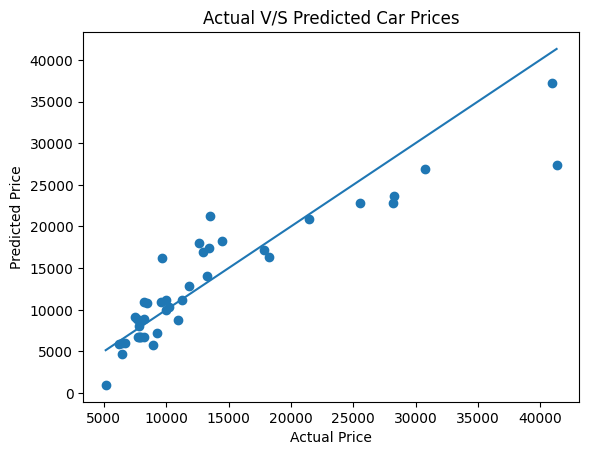

In [46]:
plt.scatter(y_test,y_pred)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()])
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual V/S Predicted Car Prices")
plt.show()

#8. Residual Analysis


##8.1 Residual Calculation

In [47]:
residual = y_test - y_pred

##8.2 Residual Plot

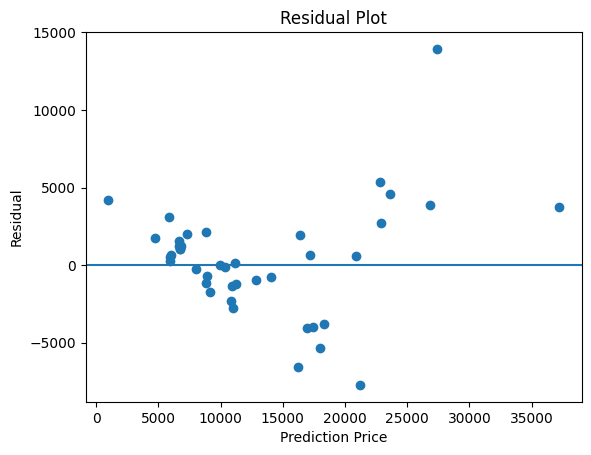

In [48]:
plt.scatter(y_pred,residual)
plt.axhline(y=0)
plt.xlabel("Prediction Price")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

##8.3 Prediction Error Analysis

In [49]:
comparison["Residual"] = y_test - y_pred

In [50]:
comparison['Absolute Error'] = abs(comparison["Residual"])

In [51]:
comparison.sort_values('Absolute Error', ascending = False)

,Actual Price,Predicted Price,Residual,Absolute Error
16,41315.000,27378.152694,13936.847306,13936.847306
101,13499.000,21217.085660,-7718.085660,7718.085660
168,9639.000,16196.909835,-6557.909835,6557.909835
69,28176.000,22788.244159,5387.755841,5387.755841
82,12629.000,17965.751668,-5336.751668,5336.751668
68,28248.000,23655.824639,4592.175361,4592.175361
18,5151.000,982.460754,4168.539246,4168.539246
194,12940.000,16974.864608,-4034.864608,4034.864608
195,13415.000,17389.942328,-3974.942328,3974.942328
15,30760.000,26867.811235,3892.188765,3892.188765


#9. Model Improvement

###9.1 Feature Selection

In [52]:
data_improved = df[
    ['enginesize', 'horsepower', 'curbweight', 'drivewheels', 'manufacturer', 'price']
]

###9.2 Train-Test Split

In [53]:
X_improved = data_improved.drop('price', axis=1)
y_improved = data_improved['price']

In [54]:
X_train_improved, X_test_improved, y_train_improved, y_test_improved = train_test_split(
    X_improved,
    y_improved,
    test_size = 0.2,
    random_state = 42
)

###9.3 Feature Classification

In [55]:
numerical_columns_improved = [
    'enginesize', 'horsepower', 'curbweight'
]

categorical_columns_improved = [
    'drivewheels', 'manufacturer'
]

###9.4 Feature Scaling

In [56]:
scaler_improved = StandardScaler()

X_train_improved[numerical_columns_improved] = scaler_improved.fit_transform(X_train_improved[numerical_columns_improved])

X_test_improved[numerical_columns_improved] = scaler_improved.transform(X_test_improved[numerical_columns_improved])

###9.5 Categorical Encoding

In [57]:
encoder_improved = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

####9.5.1 Encode Categorical Training Features

In [58]:
encoded_train_improved = encoder_improved.fit_transform(X_train_improved[categorical_columns_improved])

####9.5.2 Convert Encoded Training Features into DataFrame

In [59]:
encoded_train_improved_df = pd.DataFrame(
    encoded_train_improved,
    columns = encoder_improved.get_feature_names_out(categorical_columns_improved),
    index = X_train_improved.index
)

####9.5.3 Combine Encoded Training Features with Scaled Numerical Training Features

In [60]:
X_train_processed = pd.concat(
    [
        X_train_improved[numerical_columns_improved],
        encoded_train_improved_df
    ],
    axis=1
)

####9.5.4 Encode Categorical Test Features

In [61]:
encoded_test_improved = encoder_improved.transform(X_test_improved[categorical_columns_improved])

####9.5.5 Convert Encoded Test Features into DataFrame

In [62]:
encoded_test_improved_df = pd.DataFrame(
    encoded_test_improved,
    columns = encoder_improved.get_feature_names_out(categorical_columns_improved),
    index = X_test_improved.index
)

####9.5.6 Combine Encoded Test Features with Scaled Numerical Test Features

In [63]:
X_test_processed = pd.concat(
    [
        X_test_improved[numerical_columns_improved],
        encoded_test_improved_df
    ],
    axis=1
)

###9.6 Improved Model Training

In [64]:
model_improved = LinearRegression()

model_improved.fit(X_train_processed, y_train_improved)

LinearRegression()

###9.7 Improved Model Prediction

In [65]:
y_pred_improved = model_improved.predict(X_test_processed)

###9.8 Improved Model Evaluation

####9.8.1 Improved R² Score

In [66]:
r2_improved = r2_score(y_test_improved,y_pred_improved)

print("Improved R^2 Score :", r2_improved)

Improved R^2 Score : 0.8747281047723086


####9.8.2 Improved MAE

In [67]:
mae_improved = mean_absolute_error(y_test_improved,y_pred_improved)
print("MAE :",mae_improved)

MAE : 2138.935872968315


####9.8.3 Improved MSE

In [68]:
mse_improved = mean_squared_error(y_test_improved,y_pred_improved)
print("MSE :",mse_improved)

MSE : 9889467.11248916


9.8.4 Improved RMSE

In [69]:
rmse_improved = np.sqrt(mean_squared_error(y_test_improved,y_pred_improved))
print(rmse_improved)

3144.7523133768677


###10. Model Comparison

In [70]:
comparison = pd.DataFrame({
    "Metric" : ['R2','MAE','MSE','RMSE'],
    'Baseline Model' : [r2,mae,mse,rmse],
    'Improved Model' : [r2_improved,mae_improved,mse_improved,rmse_improved]
})

comparison

,Metric,Baseline Model,Improved Model
0,R2,8.355178e-01,8.747281e-01
1,MAE,2.513243e+03,2.138936e+03
2,MSE,1.298489e+07,9.889467e+06
3,RMSE,3.603455e+03,3.144752e+03


### 11. Final Model Selection

The improved Linear Regression model was selected as the final model because it performed better than the baseline model across all evaluation metrics.

- R² increased from **0.8355** to **0.8747**.
- MAE decreased from approximately **2,513** to **2,138**.
- MSE decreased from approximately **12,984,889** to **9,889,464**.
- RMSE decreased from approximately **3,603** to **3,144**.

Therefore, the improved model, which includes `manufacturer` as an additional feature, provides better price predictions than the baseline model.



### 12. Conclusion

A Linear Regression model was developed to predict car prices using features such as engine size, horsepower, curb weight, drive wheels, and manufacturer.

Exploratory Data Analysis showed that the numerical features have strong positive relationships with car price, while car prices also vary across drive-wheel categories and manufacturers.

The baseline model achieved an R² score of **0.8355**. After adding `manufacturer` as an additional feature, the improved model achieved an R² score of **0.8747**, along with lower MAE, MSE, and RMSE values.

Therefore, the improved Linear Regression model was selected as the final model for car price prediction. The model explains approximately **87.47% of the variation in car prices** on the test data.